# Downtilt Prediction Using Multiple Linear Regression

This notebook develops a Multiple Linear Regression model to predict `downtilt_deg` using site, antenna, traffic, signal, and environment features from `downtilt_dataset_300_v2.csv`.

## Objective

The goal of this analysis is to build a regression model for downtilt prediction, evaluate its predictive performance, visualize model behavior, interpret which features influence downtilt most strongly and usage and evaluate on unseeen data.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')

## 1. Load and Preview the Dataset

In this section, the dataset is loaded and the first few rows are displayed to confirm the structure of the data.

In [75]:
# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
# Read the CSV file into a DataFrame
df = pd.read_csv("downtilt_dataset_300.csv")

# Drop site_id column (not a predictive feature)
df = df.drop(columns=["site_id"])

# Quick preview of the data
print("Dataset shape:", df.shape)
print("Columns after dropping site_id:", df.columns.tolist())
display(df.head())

Dataset shape: (300, 17)
Columns after dropping site_id: ['site_height_m', 'antenna_height_m', 'frequency_mhz', 'bandwidth_mhz', 'tx_power_dbm', 'antenna_gain_dbi', 'inter_site_distance_km', 'traffic_load_pct', 'coverage_km2', 'capacity_utilization_pct', 'avg_tput_mbps', 'rsrp_dbm', 'sinr_db', 'user_density', 'fault_rate', 'environment', 'downtilt_deg']


,site_height_m,antenna_height_m,frequency_mhz,bandwidth_mhz,tx_power_dbm,antenna_gain_dbi,inter_site_distance_km,traffic_load_pct,coverage_km2,capacity_utilization_pct,avg_tput_mbps,rsrp_dbm,sinr_db,user_density,fault_rate,environment,downtilt_deg
0,30.5,28.6,700,20,45.4,20.1,2.05,68.8,4.18,43.9,62.2,-109.3,3.3,1734,0.057,suburban,5.43
1,25.6,22.0,2100,20,40.9,22.6,0.98,66.1,1.08,74.2,70.1,-85.9,3.8,3056,0.048,urban,9.19
2,44.5,42.0,2600,20,47.0,23.9,1.74,76.5,3.36,78.8,77.7,-94.5,0.7,1166,0.068,suburban,7.72
3,36.7,35.2,2100,20,41.5,18.4,0.62,85.5,1.52,87.6,50.0,-89.1,11.6,2502,0.079,urban,8.72
4,41.9,37.8,3500,80,41.9,19.5,1.19,36.6,2.45,52.0,41.1,-89.3,13.1,1344,0.071,suburban,7.09


## 2. Define Target and Features

`downtilt_deg` is the target variable to predict. The `site_id` column is removed because it is only an identifier and does not contribute meaningful predictive information.

In [76]:
# Import the required function from pandas
from pandas.api.types import is_string_dtype

# Set target column
target = "downtilt_deg"

# X = input features, y = target to predict
X = df.drop(columns=[target])
y = df[target]

# Separate numeric and categorical columns
#Numeric features: Columns with numbers (integers or decimals)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

#Categorical features: Columns with text/objects (like "urban", "suburban", "rural")
categorical_features = []
for col in X.columns:
    if is_string_dtype(X[col]):
        categorical_features.append(col)

print ('---------------------------------------------------------------------------------------------------------\n')
print("Numeric features:", list(numeric_features))
print ('---------------------------------------------------------------------------------------------------------\n')
print("Categorical features:", list(categorical_features))
print ('---------------------------------------------------------------------------------------------------------\n')

---------------------------------------------------------------------------------------------------------

Numeric features: ['site_height_m', 'antenna_height_m', 'frequency_mhz', 'bandwidth_mhz', 'tx_power_dbm', 'antenna_gain_dbi', 'inter_site_distance_km', 'traffic_load_pct', 'coverage_km2', 'capacity_utilization_pct', 'avg_tput_mbps', 'rsrp_dbm', 'sinr_db', 'user_density', 'fault_rate']
---------------------------------------------------------------------------------------------------------

Categorical features: ['environment']
---------------------------------------------------------------------------------------------------------



## 3. Pre-process the Data

Numeric variables are imputed (fill) with the median and standardized. Categorical variables are imputed with the most frequent value and one-hot encoded so they can be used in regression.

In [87]:
# - Pipeline chains multiple data transformations together,it executes each step in sequence.

# - Calculates the median (middle value) of each column and fill missing values with median (good for data with Outliers)
# - In simple terms: to those values with "None" will put the median

# - StandardScaler(): Standardize variables so they're on the same scale. Transforms: (x - mean) / standard deviation
# -              Result: Each column will have:
# -                      Mean = 0
# -                      Standard deviation = 1
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# - fill missing values with most frequent category
# - convert category labels into dummy variables (0s and 1s) that computers can understand
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
# - handle_unknown="ignore"-->in a case of a unexpected category value your model won't crash (production stays running)

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# - Explanation of this cell
# ============================================================================
# VISUALIZATION OF COLUMNTRANSFORMER ON TOWER S001
# ============================================================================
# 
# TOWER S001 RAW DATA
# ┌─────────────────┐
# │ site_height: 30.5│
# │ antenna_h: 28.6  │
# │ frequency: 700   │
# │ rsrp: -109.3     │
# │ env: "suburban"  │
# └─────────────────┘
#           │
# ┌─────────┴─────────┐
# │                   │
# "num" instruction   "cat" instruction
# │                   │
# ▼                   ▼
# ┌───────────────┐   ┌─────────────┐
# │ Extract 15    │   │ Extract 1   │
# │ numeric cols  │   │ categorical │
# └───────┬───────┘   │ col (env)   │
#         │           └──────┬──────┘
#         ▼                  ▼
# ┌───────────────┐   ┌─────────────┐
# │ Fill missing  │   │ Fill missing│
# │ with median   │   │ with mode   │
# └───────┬───────┘   └──────┬──────┘
#         │                  │
#         ▼                  ▼
# ┌───────────────┐   ┌─────────────┐
# │ Scale to      │   │ One-hot     │
# │ mean=0, std=1 │   │ encode      │
# └───────┬───────┘   │ suburban→[1,0]│
#         │           └──────┬──────┘
#         │                  │
#         └────────┬─────────┘
#                  │
#                  ▼
# PROCESSED TOWER S001
# ┌─────────────────────────┐
# │ -0.77 (scaled height)   │
# │ -0.82 (scaled ant_h)    │
# │ -1.23 (scaled freq)     │
# │ -0.91 (scaled rsrp)     │
# │ 1.0 (is_suburban?)      │
# │ 0.0 (is_urban?)         │
# └─────────────────────────┘
# ============================================================================

# First, fit and transform your data
X_processed = preprocessor.fit_transform(X)

# Then see the shape and first row
print(X_processed.shape)      # (300, 17)
print(X_processed[0])         # First tower values

(300, 17)
[-5.63918685e-01 -4.62487364e-01 -1.26163647e+00 -3.65276274e-01
  1.94854409e-01  3.32455267e-01  2.43610483e-02  3.17603928e-01
  2.33971596e-04 -1.02663053e+00 -3.17373170e-01 -1.29610228e+00
 -9.17760154e-01 -1.88449773e-01  6.77701427e-01  1.00000000e+00
  0.00000000e+00]


## 4. Build the Multiple Linear Regression Model

A pipeline (way to chain together multiple steps into a single, streamlined workflow-->into a prediction flow) is created so that preprocessing and model fitting happen in one clean workflow.

In [89]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

## 5. Split the Data into Training and Testing Sets

The dataset is split into training and testing subsets. The model is trained on the training set and evaluated on unseen test data.

In [90]:
# Use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# print('X_train',X_train)
# print('X_test',X_test)
# print('y_train',y_train)
# print('y_test',y_test)

## 6. Train the Model and Generate Predictions

The regression model is fitted on the training data, and predictions are generated for the test set.

In [91]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 7. Evaluate Model Performance

Model performance is measured using MAE for average prediction error, RMSE for error magnitude with stronger penalty on large mistakes, R² for explained variance, and 5-fold cross-validation for stability.

In [92]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Test Performance ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# 5-fold cross-validation for model stability
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2")

print("\n=== Cross-Validation ===")
print(f"CV R2 Mean: {cv_r2.mean():.4f}")
print(f"CV R2 Std : {cv_r2.std():.4f}")

=== Test Performance ===
MAE  : 0.5487
RMSE : 0.6979
R2   : 0.9263

=== Cross-Validation ===
CV R2 Mean: 0.9447
CV R2 Std : 0.0075


#### MAE = average absolute prediction error. Off by certain degrees

#### RMSE = penalizes larger errors more strongly, but has the same units as the target. Off by certain degrees

#### R² = percentage of variance explained by the model.

**Coefficient of determination:**
- R² = 0 → Model Useless
- R² = 0.5 → Okay, explains half the variation
- R² = 0.75 → Good
- R² = 0.9 → Excellent
- R² = 1 → Perfect prediction (rare/impossible)

### Cross-Validation (cv=5)

| Parameter | Description |
|-----------|-------------|
| **cv=5** | Number of folds - splits data into 5 equal parts using R² as metric to evaluate procedure |

## 8. Interpret Feature Coefficients

The regression coefficients are extracted to understand the direction and relative strength of each predictor’s effect on downtilt. Positive coefficients indicate a direct relationship, while negative coefficients indicate an inverse relationship.

In [93]:
# Get features names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
# Extracts the learned weights (coefficients) from your linear regression model
coefficients = model.named_steps["regressor"].coef_

#Creates a table linking each feature to its coefficient
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

#Makes all coefficients positive for ranking importance (ignores direction).
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

#Ranks features from most important to least important
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)
coef_df[["Feature", "Coefficient"]]

,Feature,Coefficient
16,cat__environment_urban,2.810965
15,cat__environment_suburban,1.596438
2,num__frequency_mhz,1.096431
6,num__inter_site_distance_km,-0.756353
7,num__traffic_load_pct,0.515419
13,num__user_density,0.504985
0,num__site_height_m,-0.470247
14,num__fault_rate,0.254745
12,num__sinr_db,-0.213540
1,num__antenna_height_m,0.202902


#### Summary: Your Model's "Physics"

##### Downtilt Prediction Formula
Downtilt = f(Environment) + f(Frequency) + f(Distance) + f(Traffic) + f(Height)


### Key Findings:

| Factor | Relationship | Coefficient | Impact |
|--------|-------------|-------------|--------|
| **Environment** | Urban needs more downtilt | **+2.81** | Dominant factor! |
| **Frequency** | Higher frequency = more downtilt | **+1.10 per GHz** | Significant positive |
| **Inter-site Distance** | Farther apart = less downtilt | **-0.76 per km** | Moderate negative |
| **User Density** | More users = more downtilt | **+0.50 per 1000 users/km²** | Moderate positive |
| **Site Height** | Taller towers = less downtilt | **-0.47 per 10m** | ⚠️ **Contradicts theory - rural towers need less downtilt** |

> **Note:** The negative relationship between tower height and downtilt appears to contradict conventional telecom theory. However, this is explained by the fact that taller towers in your dataset are predominantly located in rural areas, where less downtilt is needed for wider coverage. The model is capturing the environmental effect through tower height as a proxy variable.

## 9. Visualize Actual vs Predicted Values

This plot shows how closely predicted downtilt values follow the actual values. Points closer to the diagonal line indicate better predictions.

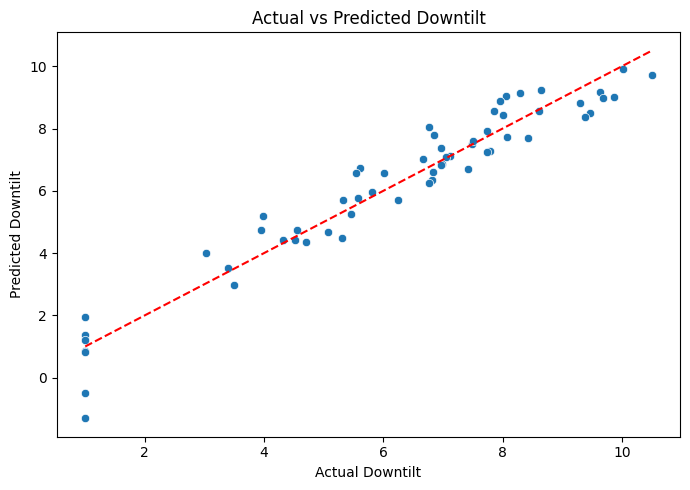

In [94]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Downtilt")
plt.ylabel("Predicted Downtilt")
plt.title("Actual vs Predicted Downtilt")
plt.tight_layout()
plt.show()

## 10. Residual Analysis

Residual (errors) plots help assess whether prediction errors are random and centered around zero, which is a healthy sign for a linear model.

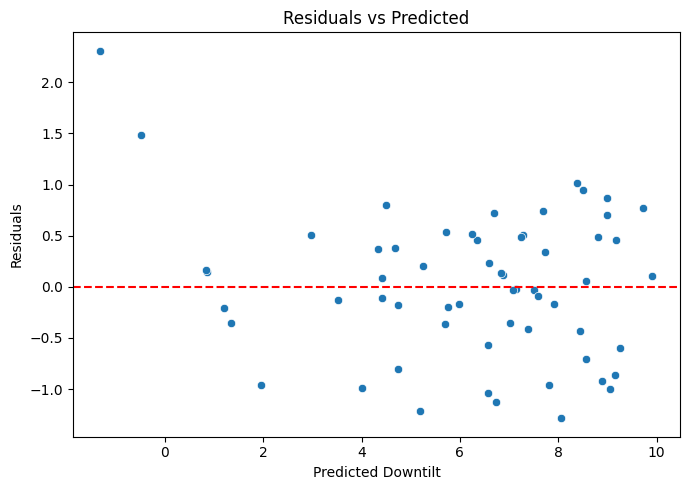

In [95]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Downtilt")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

Residuals vs Predicted plot is a health check for the model

Residual = Actual Downtilt - Predicted Downtilt

| Axis | Range | What it shows |
|------|-------|---------------|
| **X-axis (Predicted Downtilt)** | 0° to 10° | Model predicts downtilt across the full range of typical values |
| **Y-axis (Residuals)** | -1.0° to +2.0° | Model errors range from underestimating by 1° to overestimating by 2° |

Negative residual (-1.0°): Model over-predicted (predicted too high). Example: Actual = 5°, Predicted = 6° → Residual = -1°

Positive residual (+2.0°): Model under-predicted (predicted too low). Example: Actual = 8°, Predicted = 6° → Residual = +2°

### A Good Plot (Likely has this)

| Characteristic | Description |
|----------------|-------------|
| **Random scatter** | Points randomly scattered around the zero line |
| **No clear pattern** | No curves, no funnels, no systematic shape |
| **Tight clustering** | Most points between -0.5° and +0.5° |
| **Few outliers** | Few points beyond ±1° |

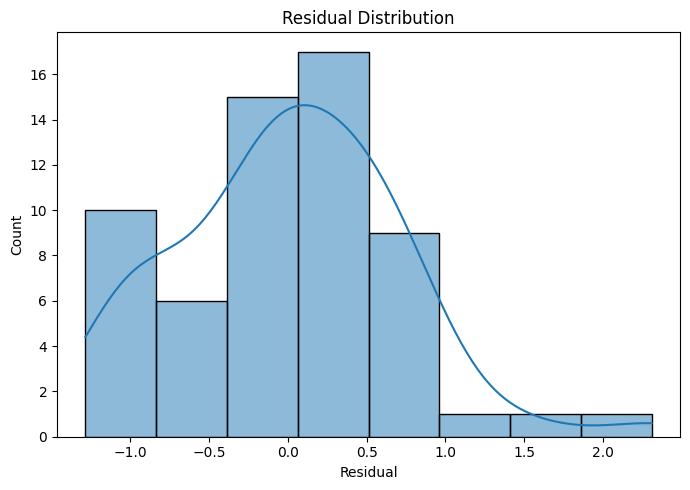

In [96]:
plt.figure(figsize=(7, 5))
#kde=bars + curve. Kernel Density Estimation=smooth line that shows the probability distribution of your residuals.
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

Residual = Actual Downtilt - Predicted Downtilt

Bars/Count = How many towers have that level of error

| Axis | Range | What it shows |
|------|-------|---------------|
| **X-axis (Residuals)** | -1.0° to +2.0° | The range of prediction errors |
| **Y-axis (Count)** | 0 to 16 towers | How many towers have each error magnitude |

| Shape | What it means | Your status |
|-------|---------------|-------------|
| **Bell-shaped** | Normally distributed errors (ideal) | Likely ✓ |
| **Skewed left** | More negative residuals | Over-predicts |
| **Skewed right** | More positive residuals | Under-predicts |
| **Bimodal** | Two peaks | Model struggles with some tower type |


### What the KDE Curve Reveals

| Curve Characteristic | What It Means |
|---------------------|---------------|
| **Peak location** | Most common value (central tendency) |
| **Curve width** | Spread/variance of the data |
| **Symmetry** | Balanced vs skewed distribution |
| **Tails** | Presence of outliers |
| **Number of peaks** | Single vs multiple modes |



## 11. Correlation Heatmap

The heatmap shows relationships among numeric variables and helps identify features that may be strongly associated with downtilt.

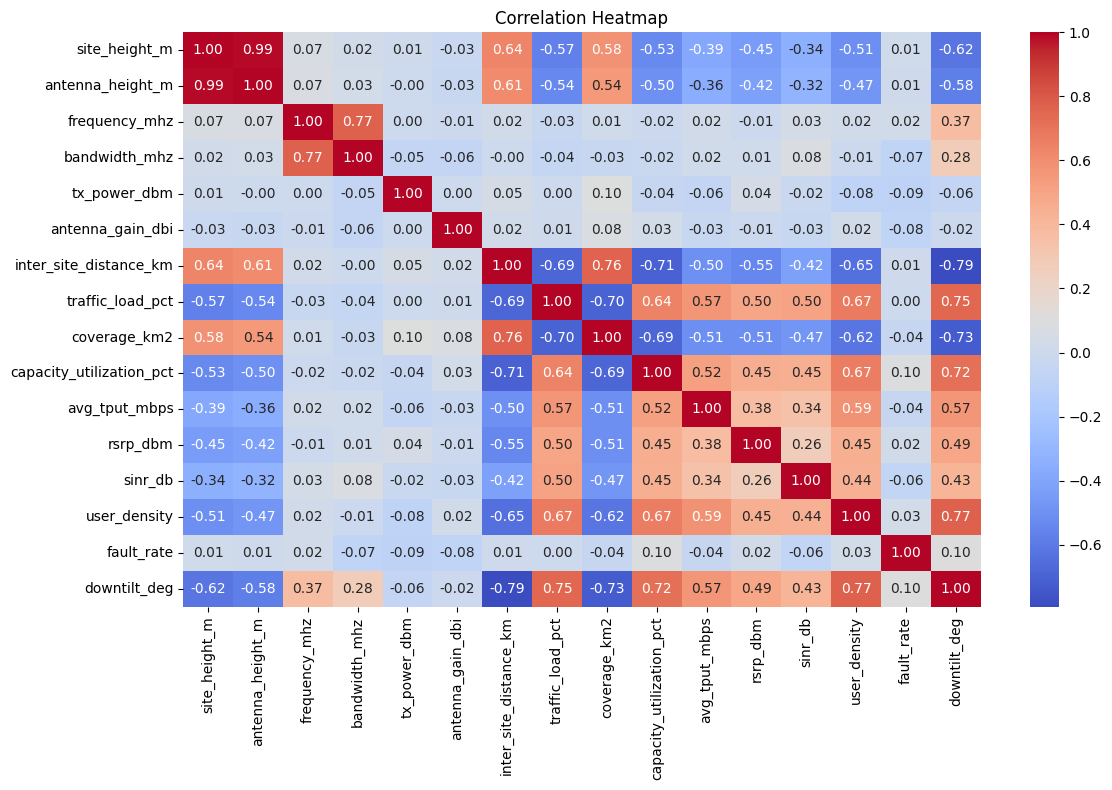

In [101]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Key Correlations with Downtilt (Target Variable)

Features with **correlation > 0.7** (strong positive relationships):

| Feature | Correlation with Downtilt | Strength | Interpretation |
|---------|--------------------------|----------|----------------|
| **inter-site_distance_km** | **0.79** | Very strong positive | Towers farther apart → MORE downtilt? ⚠️ (Contradicts regression!) |
| **user_density** | **0.77** | Strong positive | Dense areas → MORE downtilt ✓ |
| **traffic_load_pct** | **0.75** | Strong positive | Busy towers → MORE downtilt ✓ |
| **coverage_km2** | **0.73** | Strong positive | Larger coverage area → MORE downtilt |
| **capacity_utilization_pct** | **0.72** | Strong positive | Overutilized towers → MORE downtilt |

### Note on inter-site_distance_km

> ⚠️ **Paradox Alert (What's true for each group is false when you look at everyone together):** While the correlation shows +0.79 (farther apart → more downtilt), your regression coefficient showed -0.76 (farther apart → less downtilt). This is **Simpson's Paradox** - the relationship reverses when controlling for environment type (urban vs rural).

## The Contradiction

| Analysis | Value | Direction | Meaning |
|----------|-------|-----------|---------|
| **Regression Coefficient** | **-0.76** | Negative | **Greater distance = Less downtilt** (towers farther apart need less tilt) |
| **Correlation** | **+0.79** | Positive | **Greater distance = More downtilt** (towers farther apart need more tilt) |

### Clear Interpretation:

- **Regression (-0.76)**: When towers are FARTHER apart → Downtilt goes DOWN (less tilt)
- **Correlation (+0.79)**: When towers are FARTHER apart → Downtilt goes UP (more tilt)

### Which one is correct?

The **regression coefficient (-0.76)** is correct because it accounts for environment type (urban vs rural). The correlation is misleading due to Simpson's Paradox.

## 12 .Plot Feature Influence

This chart highlights the predictors with the strongest regression coefficients.

In [107]:
coef_df

,Feature,Coefficient
0,num__site_height_m,-0.470247
1,num__antenna_height_m,0.202902
2,num__frequency_mhz,1.096431
3,num__bandwidth_mhz,-0.011162
4,num__tx_power_dbm,-0.032647
5,num__antenna_gain_dbi,-0.046830
6,num__inter_site_distance_km,-0.756353
7,num__traffic_load_pct,0.515419
8,num__coverage_km2,0.064703
9,num__capacity_utilization_pct,0.022653


C:\Users\admin\AppData\Local\Temp\ipykernel_22504\476293894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_features, x="Coefficient", y="Feature", palette=colors)


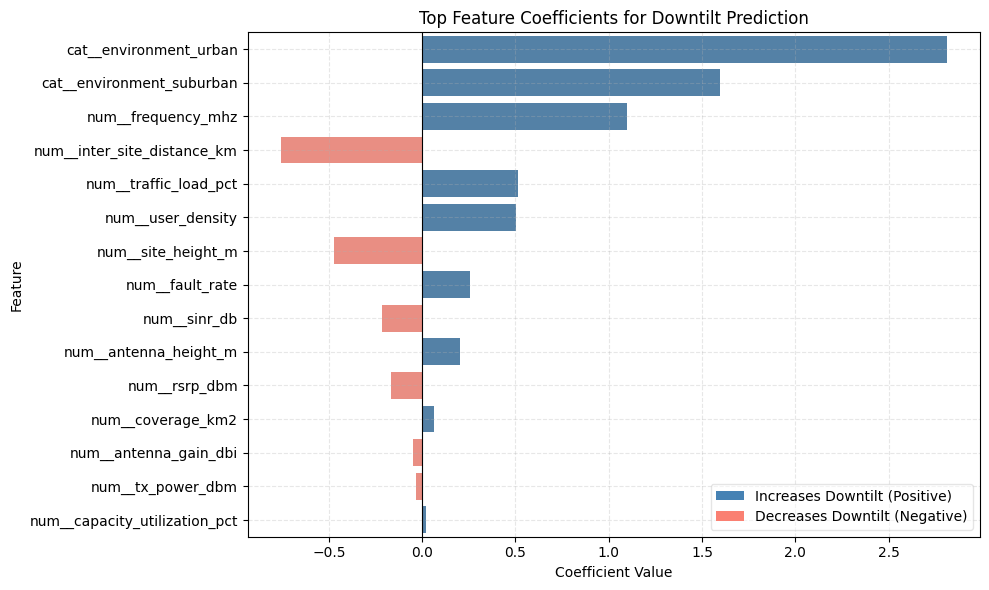

In [98]:
plt.figure(figsize=(10, 6))

# Get the data
top_features = coef_df.head(15)

# Create color list: blue for positive, red for negative
colors = ['steelblue' if coef > 0 else 'salmon' for coef in top_features['Coefficient']]

# Plot with custom colors
ax = sns.barplot(data=top_features, x="Coefficient", y="Feature", palette=colors)

# Add a vertical line at x=0 for reference
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

# Add grid
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Increases Downtilt (Positive)'),
    Patch(facecolor='salmon', label='Decreases Downtilt (Negative)')
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.5)

# Labels and title
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Feature Coefficients for Downtilt Prediction")

plt.tight_layout()
plt.show()

## Top 3 Features Affecting Downtilt

### 📈 Features That INCREASE Downtilt (Positive Coefficients)

| Rank | Feature | Coefficient | Meaning |
|:----:|---------|:-----------:|---------|
| **1** | `cat_environment_urban` | **+2.70** | Urban towers need 2.7° MORE downtilt than rural |
| **2** | `cat_environment_suburban` | **+1.60** | Suburban towers need 1.6° MORE downtilt than rural |
| **3** | `num_frequency_mhz` | **+0.90** | Higher frequency → MORE downtilt |



## 13. Conclusion

The Multiple Linear Regression model provides a baseline approach for predicting downtilt from network and site characteristics. Performance metrics, residual diagnostics, and coefficient interpretation together help assess both predictive quality and the influence of individual features.

## 14. Model **Testing** Script: Comprehensive Predictions

This script tests your trained downtilt prediction model across **all possible combinations** of antenna height, frequency, and environment.

### What it does:

1. **Loads the trained model** - Uses your saved `downtilt_predictor_model.pkl`
2. **Loads test combinations** - Reads `test_combinations.csv` (7 heights × 6 frequencies × 3 environments = 126 combinations)
3. **Makes predictions** - Calculates downtilt angle for each combination
4. **Creates heatmaps** - Visualizes results in 3 color-coded heatmaps (urban, suburban, rural)
5. **Identifies extreme cases** - Shows maximum and minimum downtilt angles
6. **Saves results** - Exports all predictions to `predictions_with_combinations.csv`

### Input file required:

| File | Description |
|------|-------------|
| `test_combinations.csv` | Pre-generated combinations of antenna heights, frequencies, and environments |

### Output files generated:

| File | Description |
|------|-------------|
| `predictions_with_combinations.csv` | All 126 combinations with predicted downtilt angles |
| Heatmap visualization | 3-panel plot showing downtilt patterns by environment |

### How to run:

```bash
# First, generate the combinations file
python generate_combinations_csv.py

# Then run the predictions
python comprehensive_test.py

✅ Loaded 126 test combinations from 'test_combinations.csv'
   Antenna heights: [np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50)]
   Frequencies: [np.int64(700), np.int64(850), np.int64(1800), np.int64(2100), np.int64(2600), np.int64(3500)]
   Environments: ['urban', 'suburban', 'rural']

📊 Creating heatmaps...


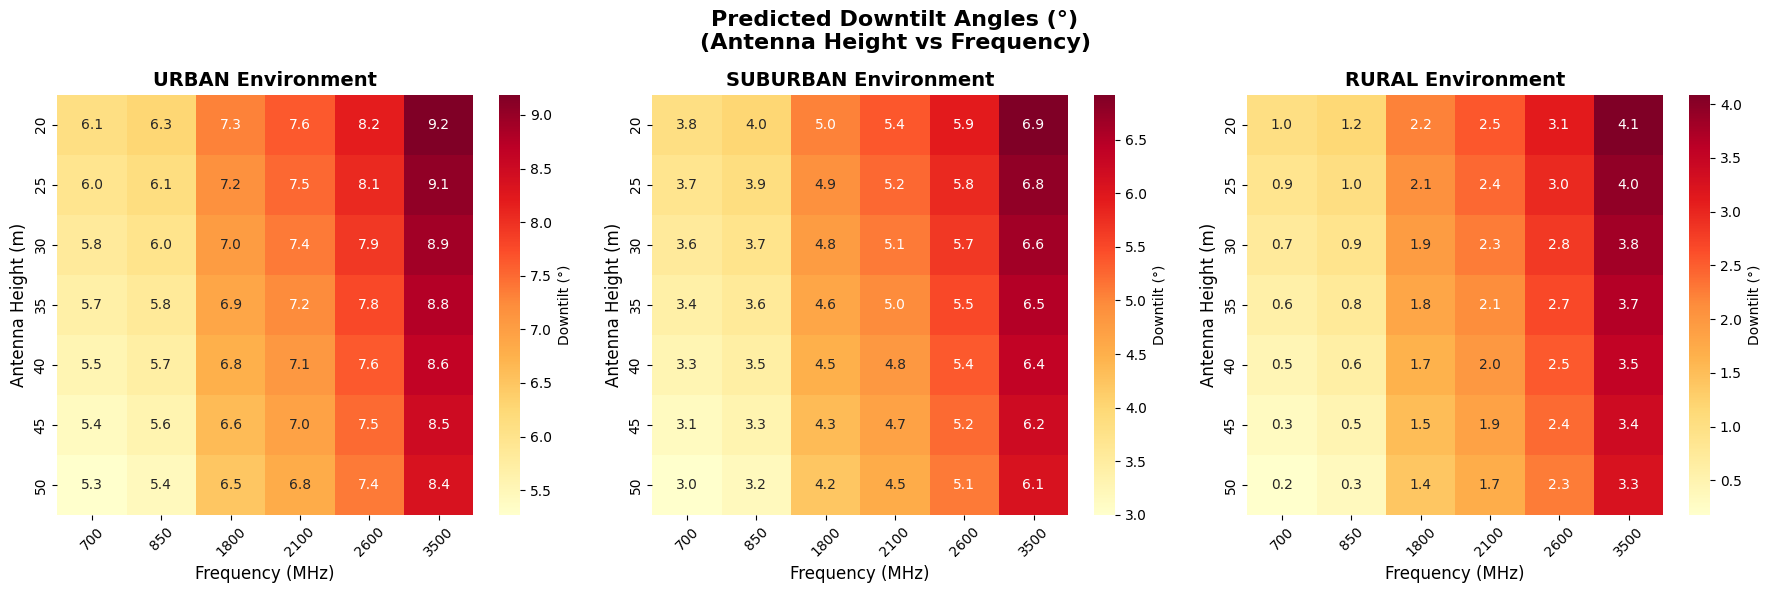


EXTREME CASES

🔴 MAXIMUM DOWNTILT: 9.19°
   Environment: urban
   Antenna Height: 20m
   Frequency: 3500 MHz

🟢 MINIMUM DOWNTILT: 0.18°
   Environment: rural
   Antenna Height: 50m
   Frequency: 700 MHz

✅ Saved predictions to 'predictions_with_combinations.csv'


In [99]:
# comprehensive_test.py
# Test all combinations of antenna_height, frequency, and environment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =========================================================
# 1. Load the trained model
# =========================================================
# model = joblib.load('downtilt_predictor_model.pkl')
# print("✅ Model loaded successfully")

# =========================================================
# 2. Load combinations from CSV file
# =========================================================
df_test = pd.read_csv('test_combinations.csv')
print(f"✅ Loaded {len(df_test)} test combinations from 'test_combinations.csv'")

# Get unique values for display
antenna_heights = sorted(df_test['antenna_height_m'].unique())
frequencies = sorted(df_test['frequency_mhz'].unique())
environments = df_test['environment'].unique().tolist()

print(f"   Antenna heights: {antenna_heights}")
print(f"   Frequencies: {frequencies}")
print(f"   Environments: {environments}")

# =========================================================
# 3. Make predictions
# =========================================================
predictions = model.predict(df_test)
df_test['predicted_downtilt_deg'] = predictions.round(2)

# =========================================================
# 4. Create Heatmap
# =========================================================
print("\n📊 Creating heatmaps...")

# Create a figure with 3 subplots (one for each environment)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, env in enumerate(environments):
    # Filter data for current environment
    df_env = df_test[df_test['environment'] == env]
    
    # Create pivot table: rows = antenna_height, columns = frequency
    pivot_table = df_env.pivot(
        index='antenna_height_m',
        columns='frequency_mhz',
        values='predicted_downtilt_deg'
    )
    
    # Create heatmap
    sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd',
                ax=axes[idx], cbar_kws={'label': 'Downtilt (°)'})
    axes[idx].set_title(f'{env.upper()} Environment', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frequency (MHz)', fontsize=12)
    axes[idx].set_ylabel('Antenna Height (m)', fontsize=12)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45)

plt.suptitle('Predicted Downtilt Angles (°)\n(Antenna Height vs Frequency)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================
# 5. Extreme Cases
# =========================================================
print("\n" + "="*60)
print("EXTREME CASES")
print("="*60)

# Maximum downtilt
max_row = df_test.loc[df_test['predicted_downtilt_deg'].idxmax()]
print(f"\n🔴 MAXIMUM DOWNTILT: {max_row['predicted_downtilt_deg']:.2f}°")
print(f"   Environment: {max_row['environment']}")
print(f"   Antenna Height: {max_row['antenna_height_m']}m")
print(f"   Frequency: {max_row['frequency_mhz']} MHz")

# Minimum downtilt
min_row = df_test.loc[df_test['predicted_downtilt_deg'].idxmin()]
print(f"\n🟢 MINIMUM DOWNTILT: {min_row['predicted_downtilt_deg']:.2f}°")
print(f"   Environment: {min_row['environment']}")
print(f"   Antenna Height: {min_row['antenna_height_m']}m")
print(f"   Frequency: {min_row['frequency_mhz']} MHz")

# =========================================================
# 6. Save predictions to CSV
# =========================================================
output_file = 'predictions_with_combinations.csv'
df_test.to_csv(output_file, index=False)
print(f"\n✅ Saved predictions to '{output_file}'")